In [8]:
import sys
import os
sys.path.append(os.path.abspath('..'))

# Data and analysis libraries
import polars as pl                         # Fast dataframes for financial data
import numpy as np                          # Numerical computing library
from datetime import datetime, timedelta    # Date and time operations
import random


# Machine learning libraries  
import torch                                # PyTorch framework
import torch.nn as nn                       # Neural network modules
import torch.optim as optim                 # Optimization algorithms
import research                             # Model building and training utilities


# Visualization and 
import altair as alt                        # Interactive visualization library

# data sources
import binance                              # Binance market data utilities

In [9]:
research.set_seed(42)

In [10]:
pl.Config.set_tbl_width_chars(200)
pl.Config.set_fmt_str_lengths(100)
pl.Config.set_tbl_cols(-1)  # Show all columns

polars.config.Config

In [11]:
# Trading pair symbol
sym = 'BTCUSDT'
# time horizon of time series (time interval)
time_interval = '1d'
# Max number of auto-regressive lags
max_lags = 4
# Forecast horizon in steps 
forecast_horizon = 1
# Sharpe annualized rate (so it's independent of time frequency)
annualized_rate = research.sharpe_annualization_factor(time_interval, 365, 24)

In [12]:
import binance
print(binance.__file__)
print([x for x in dir(binance) if "download" in x.lower()])

c:\Users\micha\Documents\Code\school\cpp\classes\spring-2026\mat_4860\quant_trading_strategy\ML-Systematic-Trading-Engine\binance.py
['download_and_unzip', 'download_date_range', 'download_ohlc_timeseries', 'download_timeseries', 'download_trades']


In [13]:
# Data is already downloaded and processed into 24h OHLC CSV
# binance.download_date_range(sym, start_date, end_date)


In [16]:
ts = pl.read_csv(f"../historical_data/{sym}_{time_interval}_ohlc_updated.csv", try_parse_dates=True).sort('datetime')
ts


datetime,open,high,low,close
datetime[μs],f64,f64,f64,f64
2025-05-05 00:00:00,94230.2,95165.1,93445.1,94696.7
2025-05-06 00:00:00,94696.7,96879.5,93327.0,96798.9
2025-05-07 00:00:00,96798.9,97700.0,95718.5,96988.4
2025-05-08 00:00:00,96988.4,104305.3,96831.5,103228.1
2025-05-09 00:00:00,103228.0,104373.0,102240.0,102941.9
…,…,…,…,…
2026-05-01 00:00:00,76305.4,78879.9,76265.4,78192.0
2026-05-02 00:00:00,78191.9,79145.0,77979.3,78652.9
2026-05-03 00:00:00,78652.8,79428.9,78027.0,78529.0


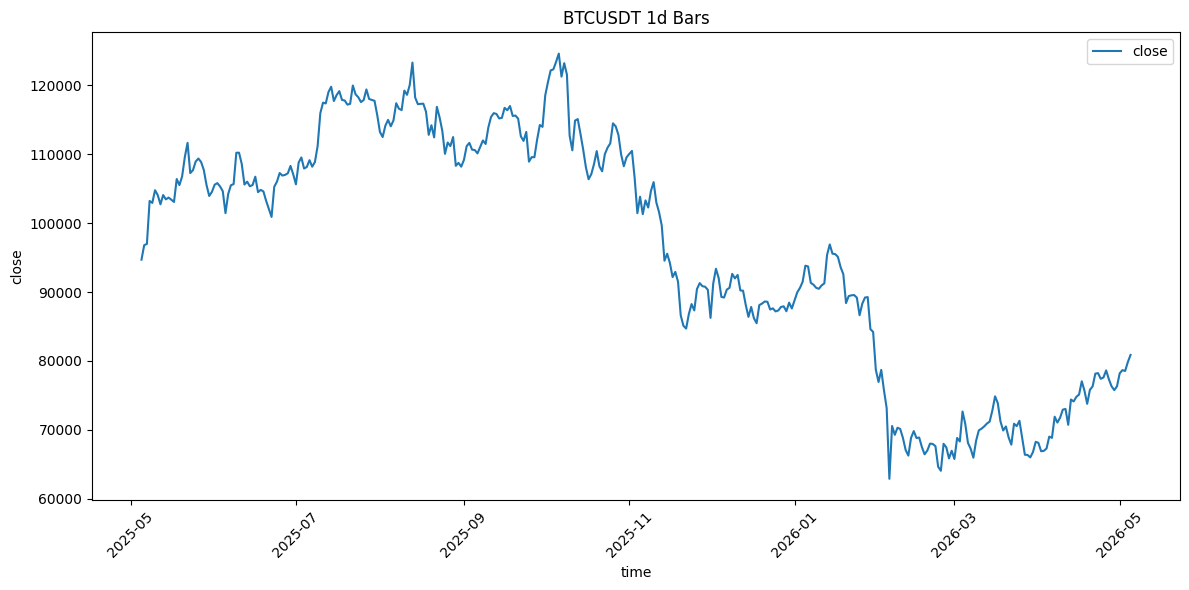

In [17]:
research.plot_static_timeseries(ts, sym, 'close', time_interval)

In [18]:
alt.data_transformers.enable("vegafusion")
research.plot_dyn_timeseries(ts, sym, 'close', time_interval)

alt.Chart(...)

### Feature Engineering

In [19]:
price_time_series = pl.DataFrame({'price':[100.0,120.0,100.0]})
research.plot_column(price_time_series, 'price')

alt.Chart(...)

In [20]:
price_time_series.with_columns(
    pl.col('price').diff().alias('delta'),
    ((pl.col('price')-pl.col('price').shift())/pl.col('price').shift()).alias('return'),
    (pl.col('price')/pl.col('price').shift()).log().alias('log_return'),
)

price,delta,return,log_return
f64,f64,f64,f64
100.0,null,null,null
120.0,20.0,0.2,0.182322
100.0,-20.0,-0.166667,-0.182322


### Create target and lagged features

In [21]:
ts = ts.with_columns((pl.col('close')/pl.col('close').shift(forecast_horizon)).log().alias('close_log_return'))
ts

datetime,open,high,low,close,close_log_return
datetime[μs],f64,f64,f64,f64,f64
2025-05-05 00:00:00,94230.2,95165.1,93445.1,94696.7,null
2025-05-06 00:00:00,94696.7,96879.5,93327.0,96798.9,0.021956
2025-05-07 00:00:00,96798.9,97700.0,95718.5,96988.4,0.001956
2025-05-08 00:00:00,96988.4,104305.3,96831.5,103228.1,0.06235
2025-05-09 00:00:00,103228.0,104373.0,102240.0,102941.9,-0.002776
…,…,…,…,…,…
2026-05-01 00:00:00,76305.4,78879.9,76265.4,78192.0,0.024424
2026-05-02 00:00:00,78191.9,79145.0,77979.3,78652.9,0.005877
2026-05-03 00:00:00,78652.8,79428.9,78027.0,78529.0,-0.001577


In [22]:
target = 'close_log_return'
lr = pl.col(target)
ts = ts.with_columns(
    lr.shift(forecast_horizon * 1).alias(f'{target}_lag_1'),
    lr.shift(forecast_horizon * 2).alias(f'{target}_lag_2'),
    lr.shift(forecast_horizon * 3).alias(f'{target}_lag_3'),
    lr.shift(forecast_horizon * 4).alias(f'{target}_lag_4'),
)
ts

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-05-05 00:00:00,94230.2,95165.1,93445.1,94696.7,null,null,null,null,null
2025-05-06 00:00:00,94696.7,96879.5,93327.0,96798.9,0.021956,null,null,null,null
2025-05-07 00:00:00,96798.9,97700.0,95718.5,96988.4,0.001956,0.021956,null,null,null
2025-05-08 00:00:00,96988.4,104305.3,96831.5,103228.1,0.06235,0.001956,0.021956,null,null
2025-05-09 00:00:00,103228.0,104373.0,102240.0,102941.9,-0.002776,0.06235,0.001956,0.021956,null
…,…,…,…,…,…,…,…,…,…
2026-05-01 00:00:00,76305.4,78879.9,76265.4,78192.0,0.024424,0.007307,-0.007211,-0.013449,-0.016446
2026-05-02 00:00:00,78191.9,79145.0,77979.3,78652.9,0.005877,0.024424,0.007307,-0.007211,-0.013449
2026-05-03 00:00:00,78652.8,79428.9,78027.0,78529.0,-0.001577,0.005877,0.024424,0.007307,-0.007211


In [23]:
ts = research.add_lags(ts, target, max_lags, forecast_horizon)
ts

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-05-05 00:00:00,94230.2,95165.1,93445.1,94696.7,null,null,null,null,null
2025-05-06 00:00:00,94696.7,96879.5,93327.0,96798.9,0.021956,null,null,null,null
2025-05-07 00:00:00,96798.9,97700.0,95718.5,96988.4,0.001956,0.021956,null,null,null
2025-05-08 00:00:00,96988.4,104305.3,96831.5,103228.1,0.06235,0.001956,0.021956,null,null
2025-05-09 00:00:00,103228.0,104373.0,102240.0,102941.9,-0.002776,0.06235,0.001956,0.021956,null
…,…,…,…,…,…,…,…,…,…
2026-05-01 00:00:00,76305.4,78879.9,76265.4,78192.0,0.024424,0.007307,-0.007211,-0.013449,-0.016446
2026-05-02 00:00:00,78191.9,79145.0,77979.3,78652.9,0.005877,0.024424,0.007307,-0.007211,-0.013449
2026-05-03 00:00:00,78652.8,79428.9,78027.0,78529.0,-0.001577,0.005877,0.024424,0.007307,-0.007211


In [24]:
ts = ts.drop_nulls()

In [25]:
research.plot_distribution(ts, target, no_bins = 100)

alt.Chart(...)

In [26]:
research.plot_distribution(ts, 'close', no_bins = 100)

alt.Chart(...)

### Build Model

In [27]:
class LinearModel(nn.Module):
    def __init__(self, input_features):
        super(LinearModel, self).__init__()
        self.linear = nn.Linear(input_features, 1)

    def forward(self, x):
        return self.linear(x)

### Complexity of the model

In [28]:
input_features = 1

linear_model = LinearModel(input_features)

research.print_model_info(linear_model, "Linear Model")
research.total_model_params(linear_model)


Linear Model

Architecture:
  LinearModel(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)

Parameter Count:
  Total parameters:      2
  Trainable parameters:  2



2

### Split by time

In [29]:
features = ['close_log_return_lag_1']
target = 'close_log_return'
test_size = 0.25

In [30]:
len(ts)

361

In [31]:
int(len(ts) * test_size)

90

In [32]:
split_idx = int(len(ts) * (1-test_size))
split_idx

270

In [33]:
ts_train, ts_test = ts[:split_idx], ts[split_idx:]

In [34]:
ts_train

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-05-10 00:00:00,102941.9,105000.1,102784.0,104788.8,0.017782,-0.002776,0.06235,0.001956,0.021956
2025-05-11 00:00:00,104788.8,104950.0,103283.3,104072.7,-0.006857,0.017782,-0.002776,0.06235,0.001956
2025-05-12 00:00:00,104072.7,105863.1,100678.0,102739.3,-0.012895,-0.006857,0.017782,-0.002776,0.06235
2025-05-13 00:00:00,102739.3,104949.2,101400.0,104082.0,0.012984,-0.012895,-0.006857,0.017782,-0.002776
2025-05-14 00:00:00,104082.0,104319.0,102536.0,103458.1,-0.006012,0.012984,-0.012895,-0.006857,0.017782
…,…,…,…,…,…,…,…,…,…
2026-01-30 00:00:00,84604.7,84697.2,81000.0,84211.4,-0.00466,-0.053583,0.000716,0.010109,0.019113
2026-01-31 00:00:00,84211.4,84239.5,75500.0,78706.8,-0.067601,-0.00466,-0.053583,0.000716,0.010109
2026-02-01 00:00:00,78706.7,79396.8,75644.0,76931.5,-0.022814,-0.067601,-0.00466,-0.053583,0.000716


In [35]:
ts_test

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2026-02-04 00:00:00,75732.4,76952.5,71838.0,73137.4,-0.034866,-0.038342,0.022632,-0.022814,-0.067601
2026-02-05 00:00:00,73137.5,73316.3,62233.3,62868.1,-0.151301,-0.034866,-0.038342,0.022632,-0.022814
2026-02-06 00:00:00,62868.1,71714.4,59800.0,70544.5,0.115205,-0.151301,-0.034866,-0.038342,0.022632
2026-02-07 00:00:00,70544.5,71690.0,67250.0,69254.2,-0.01846,0.115205,-0.151301,-0.034866,-0.038342
2026-02-08 00:00:00,69254.3,72300.0,68843.7,70288.1,0.014819,-0.01846,0.115205,-0.151301,-0.034866
…,…,…,…,…,…,…,…,…,…
2026-05-01 00:00:00,76305.4,78879.9,76265.4,78192.0,0.024424,0.007307,-0.007211,-0.013449,-0.016446
2026-05-02 00:00:00,78191.9,79145.0,77979.3,78652.9,0.005877,0.024424,0.007307,-0.007211,-0.013449
2026-05-03 00:00:00,78652.8,79428.9,78027.0,78529.0,-0.001577,0.005877,0.024424,0.007307,-0.007211


In [36]:
X_train = torch.tensor(ts_train[features].to_numpy(), dtype=torch.float32)
X_test = ts_test[features].to_torch().float()
y_train = torch.tensor(ts_train[target].to_numpy(), dtype=torch.float32)
y_test = torch.tensor(ts_test[target].to_numpy(), dtype=torch.float32)


In [37]:
X_train

tensor([[-2.7764e-03],
        [ 1.7782e-02],
        [-6.8572e-03],
        [-1.2895e-02],
        [ 1.2984e-02],
        [-6.0124e-03],
        [ 2.4752e-03],
        [-2.9190e-03],
        [-3.2214e-03],
        [ 3.1775e-02],
        [-8.2666e-03],
        [ 1.1948e-02],
        [ 2.5965e-02],
        [ 1.8559e-02],
        [-4.0120e-02],
        [ 3.9764e-03],
        [ 1.1604e-02],
        [ 3.9470e-03],
        [-4.5585e-03],
        [-1.0768e-02],
        [-2.0475e-02],
        [-1.5179e-02],
        [ 5.7047e-03],
        [ 9.8855e-03],
        [ 2.1855e-03],
        [-4.5864e-03],
        [-6.5561e-03],
        [-3.0892e-02],
        [ 2.7045e-02],
        [ 1.2086e-02],
        [ 1.6005e-03],
        [ 4.2167e-02],
        [ 6.8039e-05],
        [-1.4947e-02],
        [-2.7923e-02],
        [ 3.9483e-03],
        [-6.3145e-03],
        [ 1.6568e-03],
        [ 1.1452e-02],
        [-2.1227e-02],
        [ 3.1031e-03],
        [-2.1553e-03],
        [-1.3096e-02],
        [-1

In [38]:
X_train.shape

torch.Size([270, 1])

In [39]:
y_train

tensor([ 1.7782e-02, -6.8572e-03, -1.2895e-02,  1.2984e-02, -6.0124e-03,
         2.4752e-03, -2.9190e-03, -3.2214e-03,  3.1775e-02, -8.2666e-03,
         1.1948e-02,  2.5965e-02,  1.8559e-02, -4.0120e-02,  3.9764e-03,
         1.1604e-02,  3.9470e-03, -4.5585e-03, -1.0768e-02, -2.0475e-02,
        -1.5179e-02,  5.7047e-03,  9.8855e-03,  2.1855e-03, -4.5864e-03,
        -6.5561e-03, -3.0892e-02,  2.7045e-02,  1.2086e-02,  1.6005e-03,
         4.2167e-02,  6.8039e-05, -1.4947e-02, -2.7923e-02,  3.9483e-03,
        -6.3145e-03,  1.6568e-03,  1.1452e-02, -2.1227e-02,  3.1031e-03,
        -2.1553e-03, -1.3096e-02, -1.1361e-02, -1.1578e-02,  4.2550e-02,
         7.0413e-03,  1.1674e-02, -3.4203e-03,  9.0686e-04,  2.1498e-03,
         9.9170e-03, -1.1350e-02, -1.3628e-02,  2.9494e-02,  6.8259e-03,
        -1.4804e-02,  2.0177e-03,  9.1340e-03, -8.6672e-03,  6.1656e-03,
         2.1146e-02,  4.2081e-02,  1.3027e-02, -9.4257e-04,  1.3950e-02,
         6.5161e-03, -1.7495e-02,  7.2120e-03,  4.9

In [40]:
y_train.shape

torch.Size([270])

In [41]:
y_train = y_train.reshape(-1, 1)
y_train

tensor([[ 1.7782e-02],
        [-6.8572e-03],
        [-1.2895e-02],
        [ 1.2984e-02],
        [-6.0124e-03],
        [ 2.4752e-03],
        [-2.9190e-03],
        [-3.2214e-03],
        [ 3.1775e-02],
        [-8.2666e-03],
        [ 1.1948e-02],
        [ 2.5965e-02],
        [ 1.8559e-02],
        [-4.0120e-02],
        [ 3.9764e-03],
        [ 1.1604e-02],
        [ 3.9470e-03],
        [-4.5585e-03],
        [-1.0768e-02],
        [-2.0475e-02],
        [-1.5179e-02],
        [ 5.7047e-03],
        [ 9.8855e-03],
        [ 2.1855e-03],
        [-4.5864e-03],
        [-6.5561e-03],
        [-3.0892e-02],
        [ 2.7045e-02],
        [ 1.2086e-02],
        [ 1.6005e-03],
        [ 4.2167e-02],
        [ 6.8039e-05],
        [-1.4947e-02],
        [-2.7923e-02],
        [ 3.9483e-03],
        [-6.3145e-03],
        [ 1.6568e-03],
        [ 1.1452e-02],
        [-2.1227e-02],
        [ 3.1031e-03],
        [-2.1553e-03],
        [-1.3096e-02],
        [-1.1361e-02],
        [-1

In [42]:
y_train.shape

torch.Size([270, 1])

In [43]:
y_test = y_test.reshape(-1, 1)
y_test

tensor([[-0.0349],
        [-0.1513],
        [ 0.1152],
        [-0.0185],
        [ 0.0148],
        [-0.0025],
        [-0.0188],
        [-0.0258],
        [-0.0122],
        [ 0.0382],
        [ 0.0141],
        [-0.0144],
        [ 0.0010],
        [-0.0203],
        [-0.0157],
        [ 0.0083],
        [ 0.0149],
        [-0.0007],
        [-0.0047],
        [-0.0452],
        [-0.0092],
        [ 0.0594],
        [-0.0074],
        [-0.0242],
        [ 0.0166],
        [-0.0179],
        [ 0.0454],
        [-0.0074],
        [ 0.0617],
        [-0.0249],
        [-0.0399],
        [-0.0126],
        [-0.0195],
        [ 0.0366],
        [ 0.0218],
        [ 0.0035],
        [ 0.0047],
        [ 0.0059],
        [ 0.0039],
        [ 0.0223],
        [ 0.0280],
        [-0.0131],
        [-0.0368],
        [-0.0186],
        [ 0.0083],
        [-0.0228],
        [-0.0154],
        [ 0.0438],
        [-0.0048],
        [ 0.0109],
        [-0.0358],
        [-0.0359],
        [-0.

In [44]:
research.timeseries_train_test_split(ts, features, target, test_size)

(tensor([[-2.7764e-03],
         [ 1.7782e-02],
         [-6.8572e-03],
         [-1.2895e-02],
         [ 1.2984e-02],
         [-6.0124e-03],
         [ 2.4752e-03],
         [-2.9190e-03],
         [-3.2214e-03],
         [ 3.1775e-02],
         [-8.2666e-03],
         [ 1.1948e-02],
         [ 2.5965e-02],
         [ 1.8559e-02],
         [-4.0120e-02],
         [ 3.9764e-03],
         [ 1.1604e-02],
         [ 3.9470e-03],
         [-4.5585e-03],
         [-1.0768e-02],
         [-2.0475e-02],
         [-1.5179e-02],
         [ 5.7047e-03],
         [ 9.8855e-03],
         [ 2.1855e-03],
         [-4.5864e-03],
         [-6.5561e-03],
         [-3.0892e-02],
         [ 2.7045e-02],
         [ 1.2086e-02],
         [ 1.6005e-03],
         [ 4.2167e-02],
         [ 6.8039e-05],
         [-1.4947e-02],
         [-2.7923e-02],
         [ 3.9483e-03],
         [-6.3145e-03],
         [ 1.6568e-03],
         [ 1.1452e-02],
         [-2.1227e-02],
         [ 3.1031e-03],
         [-2.155

### Batch Gradient Descent

In [45]:
# hyperparameters
no_epochs = 1000 * 5
lr = 0.0005

# create model
model = LinearModel(len(features))
# lose function
criterion = nn.MSELoss()
# optimizer
optimizer = optim.Adam(model.parameters(), lr = lr)

print("\nTraining model...")

for epoch in range(no_epochs):
    # forward pass
    y_hat = model(X_train)
    loss = criterion(y_hat, y_train)

    # backward pass
    optimizer.zero_grad()   # 1. clear old gradients
    loss.backward()         # 2. compute new gradients
    optimizer.step()        # 3. update weights

    # check for improvement
    train_loss = loss.item()

    # logging
    if (epoch + 1) % 500 == 0:
        print(f"Epoch [{epoch+1}/{no_epochs}], Loss: {train_loss:.6f}")

print("\nLearned parameters")

for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"{name}:\n{param.data.numpy()}")

# Evaluation
model.eval()
with torch.no_grad():
    y_hat = model(X_test)
    test_loss = criterion(y_hat, y_test)
    print(f"\nTest Loss: {test_loss.item():.6f}, Train Loss: {train_loss:.6f}")

    



Training model...
Epoch [500/5000], Loss: 0.470865
Epoch [1000/5000], Loss: 0.235932
Epoch [1500/5000], Loss: 0.102610
Epoch [2000/5000], Loss: 0.036764
Epoch [2500/5000], Loss: 0.010227
Epoch [3000/5000], Loss: 0.002219
Epoch [3500/5000], Loss: 0.000586
Epoch [4000/5000], Loss: 0.000381
Epoch [4500/5000], Loss: 0.000363
Epoch [5000/5000], Loss: 0.000361

Learned parameters
linear.weight:
[[0.07316587]]
linear.bias:
[-0.00099711]

Test Loss: 0.000918, Train Loss: 0.000361


### Test Trading Performance

In [46]:
trade_results = pl.DataFrame({
    'y_hat': y_hat.squeeze(),
    'y': y_test.squeeze()
}).with_columns(
    (pl.col('y_hat').sign()==pl.col('y').sign()).alias('is_won'),
    pl.col('y_hat').sign().alias('signal'),
).with_columns(
    (pl.col('signal') * pl.col('y')).alias('trade_log_return')
).with_columns(
    pl.col('trade_log_return').cum_sum().alias('equity_curve')
)
trade_results

# note for self, trade_log_return a sign (-1 or 1) of actual y (the actual log return of actual data), because you want to see your 
# actual earnings and losings if you had acted on your signal (the magnitude of the signal not accounted for for now)

y_hat,y,is_won,signal,trade_log_return,equity_curve
f32,f32,bool,f32,f32,f32
-0.003802,-0.034866,true,-1.0,0.034866,0.034866
-0.003548,-0.151301,true,-1.0,0.151301,0.186167
-0.012067,0.115205,false,-1.0,-0.115205,0.070962
0.007432,-0.01846,false,1.0,-0.01846,0.052502
-0.002348,0.014819,false,-1.0,-0.014819,0.037684
…,…,…,…,…,…
-0.000463,0.024424,false,-1.0,-0.024424,-0.179913
0.00079,0.005877,true,1.0,0.005877,-0.174035
-0.000567,-0.001577,true,-1.0,0.001577,-0.172459


In [47]:
research.plot_column(trade_results, 'equity_curve')

alt.Chart(...)

In [48]:
trade_results = trade_results.with_columns(
    (pl.col('equity_curve')-pl.col('equity_curve').cum_max()).alias('drawdown_log')
)
trade_results

y_hat,y,is_won,signal,trade_log_return,equity_curve,drawdown_log
f32,f32,bool,f32,f32,f32,f32
-0.003802,-0.034866,true,-1.0,0.034866,0.034866,0.0
-0.003548,-0.151301,true,-1.0,0.151301,0.186167,0.0
-0.012067,0.115205,false,-1.0,-0.115205,0.070962,-0.115205
0.007432,-0.01846,false,1.0,-0.01846,0.052502,-0.133665
-0.002348,0.014819,false,-1.0,-0.014819,0.037684,-0.148483
…,…,…,…,…,…,…
-0.000463,0.024424,false,-1.0,-0.024424,-0.179913,-0.36608
0.00079,0.005877,true,1.0,0.005877,-0.174035,-0.360203
-0.000567,-0.001577,true,-1.0,0.001577,-0.172459,-0.358626


In [49]:
max_drawdown_log = trade_results['drawdown_log'].min()
max_drawdown_log

-0.3750087022781372

In [50]:
# simple drawdown (a perentage, 13% here)
drawdown_pct = np.exp(max_drawdown_log) - 1
drawdown_pct

np.float64(-0.31271670216546854)

In [51]:
# if your equity (balance, net ownership) peak is $1000, this max drawdown means you would lose $136
equity_peak = 1000
equity_peak * drawdown_pct

np.float64(-312.7167021654685)

In [52]:
win_rate = trade_results['is_won'].mean()
win_rate

0.42857142857142855

In [53]:
# Expected value (win rate not end all be all, need to see how much we win or loss, take that into account in expected value). 
avg_win = trade_results.filter(pl.col('is_won')==True)['trade_log_return'].mean()
avg_loss = trade_results.filter(pl.col('is_won')==False)['trade_log_return'].mean()
ev = win_rate * avg_win + (1 - win_rate) * avg_loss
ev
# here we get a very small number, we have a very small edge

-0.0019335086479179246

In [54]:
total_log_return = trade_results['trade_log_return'].sum()
total_log_return
# very small number, but higher than video even tho our win rate is lower. We have a high ev. and there total log return is higher

-0.17594924569129944

In [55]:
compound_return = np.exp(total_log_return)
compound_return
# very tiny, also if you factor in transaction fees, this will prb be negative

np.float64(0.8386605478932403)

In [56]:
# if we put 1000 dollars into this model / traded 1000 dollars with this model, we make 20 bucks. We might lose money beacuse of transaction fees
1000*compound_return

np.float64(838.6605478932403)

In [57]:
# lowest peak of equity curve, important because it tells us how much money we lose if we start losing money
# its negative in this case, so if we had a thousand to begin with, at some point it will drop below 1000. If were are using leverage
# we have to be very careful of the equity trough (and drawndown as well)
equity_trough = trade_results['equity_curve'].min()
equity_trough

-0.18884149193763733

In [58]:
equity_peak = trade_results['equity_curve'].max()
equity_peak
# 9% here in log space

0.18616719543933868

In [59]:
std = trade_results['trade_log_return'].std()
std
# std dev is a measure of risk (std dev of log returns)

0.02987871877849102

In [60]:
# calculate the reward to risk, using the sharpe ratio, expected value, divided by std dev, multiplied by annualized rate, which is the square root of
# the number of trading periods. This gives us our annualized sharpe. This is the most common measure of risk-adjusted returns, what's our return
# with regards to risk?

sharpe = ev / std * annualized_rate
sharpe

# this should be a high number, from 6 to double digit, but you can see here it's almost 0. Not good. This is not a good model, but its just a baseline
# we are going to learn how to benchmark our model and how we can improve on our model

np.float64(-1.2363191047472366)

In [61]:
# all these benchmarks are quite tedious to do, so the creator has a method (in the custom research.py library) to do it all for us
# will be useful when comparing different models, and putting it al into a dataframe sorting by a certain metric, to see how the models did
research.eval_model_performance(y_test, y_hat, features, target, annualized_rate)

{'features': 'close_log_return_lag_1',
 'target': 'close_log_return',
 'no_trades': 91,
 'win_rate': 0.42857142857142855,
 'avg_win': 0.021160086104944825,
 'avg_loss': -0.019253704712564986,
 'best_trade': 0.15130098164081573,
 'worst_trade': -0.1152048334479332,
 'ev': -0.0019335086479179246,
 'std': 0.02987871877849102,
 'total_log_return': -0.17594924569129944,
 'compound_return': np.float64(0.8386605478932403),
 'max_drawdown': -0.3750087022781372,
 'equity_trough': -0.18884149193763733,
 'equity_peak': 0.18616719543933868,
 'sharpe': np.float64(-1.236319104747236)}

In [62]:
target = 'close_log_return'
features = ['close_log_return_lag_2']
model = LinearModel(len(features))
perf = research.benchmark_reg_model(ts, features, target, model, annualized_rate, no_epochs=50)
perf

# as you can see from the weights (weight) its a mean reversion model, linear models are easier to interpret as opposed to a neutral network 
# with a billion parameters

{'features': 'close_log_return_lag_2',
 'target': 'close_log_return',
 'no_trades': 91,
 'win_rate': 0.4835164835164835,
 'avg_win': 0.022357558383108964,
 'avg_loss': -0.01792986030403049,
 'best_trade': 0.1152048334479332,
 'worst_trade': -0.15130098164081573,
 'ev': 0.0015497707095314447,
 'std': 0.029901325702667236,
 'total_log_return': 0.14102914929389954,
 'compound_return': np.float64(1.1514582116893881),
 'max_drawdown': -0.15130098164081573,
 'equity_trough': -0.11643476784229279,
 'equity_peak': 0.22137290239334106,
 'sharpe': np.float64(0.9902011745803392),
 'weights': '[-0.03134777]',
 'biases': '-0.00025908934185281396'}

In [63]:
import itertools

benchmarks = []
feature_pool = [f'{target}_lag_{i}' for i in range(1, max_lags + 1)]
combos = list(itertools.combinations(feature_pool, 1))      
# itertools good for looking at combination of 2 or more features, for 1 its overkill, but good to introduce it

for features in combos:
    model = LinearModel(len(features))
    benchmarks.append(research.benchmark_reg_model(ts, list(features), target, model, annualized_rate, no_epochs=200, loss=nn.L1Loss()))
    # using minimum abs error for loss function this time, called L1Loss in PyTorch, better if your data has outliers

benchmark = pl.DataFrame(benchmarks)
benchmark.sort('sharpe', descending=True)      # sort by your preferred metric, sharpe seems like a good one

# based on these metrics lag_2 model would be the one we go with, but we haven't factored in transaction fees, let's see what happens

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_3""","""close_log_return""",91,0.549451,0.022096,-0.017601,0.151301,-0.059437,0.00421,0.029641,0.383128,1.466865,-0.125559,-0.034866,0.420407,2.713652,"""[-0.03069113]""","""-0.0001744316832628101"""
"""close_log_return_lag_2""","""close_log_return""",91,0.483516,0.022358,-0.01793,0.115205,-0.151301,0.00155,0.029901,0.141029,1.151458,-0.151301,-0.116435,0.221373,0.990201,"""[-0.03102451]""","""-0.00024315775954164565"""
"""close_log_return_lag_1""","""close_log_return""",91,0.494505,0.019814,-0.020322,0.151301,-0.115205,-0.000474,0.029938,-0.043177,0.957742,-0.293036,-0.106869,0.186167,-0.302785,"""[0.06744387]""","""3.2642401492921636e-05"""
"""close_log_return_lag_4""","""close_log_return""",91,0.483516,0.01915,-0.020933,0.059437,-0.151301,-0.001552,0.029901,-0.141254,0.868269,-0.284966,-0.319832,0.002195,-0.991783,"""[-0.07168324]""","""6.296824722085148e-05"""


In [64]:
research.auto_reg_corr_matrx(ts, target, max_lags)
# as you can see, close_log_return (target) doesn't exacly have the strongest correlation to lag_2, so dont just judge a feature by its
# correlation to the target, esp if we are customzing the learning alg and the loss function

close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
f64,f64,f64,f64,f64
1.0,-0.059067,-0.019792,-0.066197,-0.01337
-0.059067,1.0,-0.06051,-0.019756,-0.06689
-0.019792,-0.06051,1.0,-0.058924,-0.012351
-0.066197,-0.019756,-0.058924,1.0,-0.058499
-0.01337,-0.06689,-0.012351,-0.058499,1.0


In [65]:
features = ['close_log_return_lag_2']
model = LinearModel(len(features))
model_trades = research.learn_model_trades(ts, features, target, model, no_epochs=200, loss=nn.L1Loss())

research.plot_column(model_trades, 'equity_curve')

# mostly positive, only some negative, more stable, which is good. But there is a big drawdown in the middle, which could be dangerous if we 
# are using a lot of leverage, like 20x. Small amout of leverage, this would suffice, so it really depends on the amount of risk you are 
# willing to tolerate. But for our purposes, we will use this to build our strategy. We will also explore if we might get liquidated if we use
# say, 8x leverage, or 10x, etc. One thing we haven't taken into account is transactions fees, we will look at that next

alt.Chart(...)

### Add Transaction Fees

In [66]:
maker_fee = 0.0001      # fee for providing market liquidity (placing limits orders)
taker_fee = 0.0003      # fee for making immediate market orders 
                        # taker fee usually higher than market fee to encourage market stability, but both transactions cost 
                        # money to make the exchange momey

roundtrip_fee_log = np.log(1 - 2 * maker_fee) # two taker fees because we are open and close a trade Immediately (so market orders both times)
                                              # changed to maker fee later on to test it, usually if you want a lot of trades, the market 
                                              # rewards you for that high volume with lower fees and even rebates

model_trades = model_trades.with_columns(pl.lit(roundtrip_fee_log).alias('tx_fee_log'))
model_trades = model_trades.with_columns((pl.col("trade_log_return") + pl.col('tx_fee_log')).alias('trade_log_return_net'))
model_trades = model_trades.with_columns(pl.col('trade_log_return_net').cum_sum().alias('equity_curve_net'))
model_trades


y_pred,y_true,is_won,position,trade_log_return,equity_curve,drawdown_log_return,tx_fee_log,trade_log_return_net,equity_curve_net
f32,f32,bool,f32,f32,f32,f32,f64,f64,f64
-0.000969,-0.034866,true,-1.0,0.034866,0.034866,0.0,-0.0002,0.034666,0.034666
0.000944,-0.151301,false,1.0,-0.151301,-0.116435,-0.151301,-0.0002,-0.151501,-0.116835
0.000835,0.115205,true,1.0,0.115205,-0.00123,-0.036096,-0.0002,0.115005,-0.00183
0.004488,-0.01846,false,1.0,-0.01846,-0.01969,-0.054556,-0.0002,-0.01866,-0.02049
-0.003874,0.014819,false,-1.0,-0.014819,-0.034509,-0.069375,-0.0002,-0.015019,-0.035509
…,…,…,…,…,…,…,…,…,…
-0.000033,0.024424,false,-1.0,-0.024424,0.174605,-0.046768,-0.0002,-0.024624,0.157203
-0.000488,0.005877,false,-1.0,-0.005877,0.168727,-0.052645,-0.0002,-0.006077,0.151126
-0.001026,-0.001577,true,-1.0,0.001577,0.170304,-0.051069,-0.0002,0.001376,0.152502


In [67]:
research.plot_column(model_trades, 'equity_curve_net')
# we have stable returns, but unfortunately stable negative returns. transactions fee magnifies our losses and decreases our average win,
# so its really reducing our expected value, if fees were lower maybe we'd be fine but they are high, cause us to lose money despite a >50% win
# rate and positive ev before. this is why we need to factor in transactions fees into our model. Without transaction fees, we'd have an edge
# what this tells us is that we can't trade on a 1 hour basis. With maker fees, you have lower loses but loses nonetheless. 
# Now what we need to do is to look at different time intervals, maybe longer time intervals, like 8 hours or 12 hours

alt.Chart(...)

In [68]:
model_trades['is_won'].mean()   # statistics of model haven't changed, just transactions fees tanked the equity curve

0.4835164835164835

In [69]:
model_trades = research.add_tx_fees_log(model_trades, maker_fee, taker_fee)
model_trades
# to make modeling maker and taker fees easier, this add_tx_fees method has been implemented and shows the net equity for both maker and taker
# fees

y_pred,y_true,is_won,position,trade_log_return,equity_curve,drawdown_log_return,tx_fee_log,trade_log_return_net,equity_curve_net,trade_log_return_net_maker,trade_log_return_net_taker,equity_curve_net_maker,equity_curve_net_taker
f32,f32,bool,f32,f32,f32,f32,f64,f64,f64,f64,f64,f64,f64
-0.000969,-0.034866,true,-1.0,0.034866,0.034866,0.0,-0.0002,0.034666,0.034666,-9.175474,-8.076862,-9.175474,-8.076862
0.000944,-0.151301,false,1.0,-0.151301,-0.116435,-0.151301,-0.0002,-0.151501,-0.116835,-9.361641,-8.263029,-18.537116,-16.339891
0.000835,0.115205,true,1.0,0.115205,-0.00123,-0.036096,-0.0002,0.115005,-0.00183,-9.095136,-7.996523,-27.632251,-24.336414
0.004488,-0.01846,false,1.0,-0.01846,-0.01969,-0.054556,-0.0002,-0.01866,-0.02049,-9.2288,-8.130188,-36.861051,-32.466602
-0.003874,0.014819,false,-1.0,-0.014819,-0.034509,-0.069375,-0.0002,-0.015019,-0.035509,-9.225159,-8.126547,-46.08621,-40.593149
…,…,…,…,…,…,…,…,…,…,…,…,…,…
-0.000033,0.024424,false,-1.0,-0.024424,0.174605,-0.046768,-0.0002,-0.024624,0.157203,-9.234764,-8.136152,-801.125008,-705.545739
-0.000488,0.005877,false,-1.0,-0.005877,0.168727,-0.052645,-0.0002,-0.006077,0.151126,-9.216218,-8.117605,-810.341225,-713.663344
-0.001026,-0.001577,true,-1.0,0.001577,0.170304,-0.051069,-0.0002,0.001376,0.152502,-9.208764,-8.110152,-819.549989,-721.773496


In [70]:
# Already using 8h data from the start!


In [71]:
no_lags = 3
ts = research.add_log_return_features(ts, 'close', forecast_horizon, max_no_lags=no_lags)
ts
# we've created a new time series, and added the features, now we're gonna build the model again

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-05-10 00:00:00,102941.9,105000.1,102784.0,104788.8,null,null,null,null,0.021956
2025-05-11 00:00:00,104788.8,104950.0,103283.3,104072.7,-0.006857,null,null,null,0.001956
2025-05-12 00:00:00,104072.7,105863.1,100678.0,102739.3,-0.012895,-0.006857,null,null,0.06235
2025-05-13 00:00:00,102739.3,104949.2,101400.0,104082.0,0.012984,-0.012895,-0.006857,null,-0.002776
2025-05-14 00:00:00,104082.0,104319.0,102536.0,103458.1,-0.006012,0.012984,-0.012895,-0.006857,0.017782
…,…,…,…,…,…,…,…,…,…
2026-05-01 00:00:00,76305.4,78879.9,76265.4,78192.0,0.024424,0.007307,-0.007211,-0.013449,-0.016446
2026-05-02 00:00:00,78191.9,79145.0,77979.3,78652.9,0.005877,0.024424,0.007307,-0.007211,-0.013449
2026-05-03 00:00:00,78652.8,79428.9,78027.0,78529.0,-0.001577,0.005877,0.024424,0.007307,-0.007211


In [72]:
target = 'close_log_return'
feature_pool = [f'{target}_lag_{i}' for i in range(1, no_lags + 1)]
research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, loss=nn.HuberLoss())
# new loss function huber loss (mix of mse and min abs error cause a higher sharpe)
# also a mean reversion model, quite common for interday trading to have mean reversion

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_2""","""close_log_return""",90,0.455556,0.020585,-0.019338,0.115205,-0.151301,-0.001151,0.02986,-0.103582,0.901602,-0.294887,-0.151301,0.191305,-0.736387,"""[-0.05910484]""","""-0.001383376307785511"""
"""close_log_return_lag_3""","""close_log_return""",90,0.5,0.017664,-0.022149,0.151301,-0.115205,-0.002243,0.029797,-0.201852,0.817216,-0.353153,-0.201852,0.151301,-1.438032,"""[0.04773125]""","""-0.0012689887080341578"""
"""close_log_return_lag_1""","""close_log_return""",90,0.433333,0.020062,-0.019788,0.151301,-0.115205,-0.00252,0.029774,-0.226767,0.797106,-0.378068,-0.226767,0.151301,-1.616748,"""[0.0559122]""","""-0.001265286118723452"""


In [73]:
research.auto_reg_corr_matrx(ts.drop_nulls(), target, no_lags)
# correlation doesnt necessary mean that feature is the one to use, but here it actually looks like it is (at least
# in terms of magnitude, in terms of absolute, yeah I guess you could say its the minium correlated? cuz its negatively correlated). 
# Test empircally always

close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3
f64,f64,f64,f64
1.0,-0.057903,-0.024953,-0.066784
-0.057903,1.0,-0.060173,-0.025358
-0.024953,-0.060173,1.0,-0.059702
-0.066784,-0.025358,-0.059702,1.0


In [74]:
research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, loss=nn.MSELoss())
# mse looks exactly the same

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_2""","""close_log_return""",90,0.455556,0.020585,-0.019338,0.115205,-0.151301,-0.001151,0.02986,-0.103582,0.901602,-0.294887,-0.151301,0.191305,-0.736387,"""[-0.05914238]""","""-0.0013843660708516836"""
"""close_log_return_lag_1""","""close_log_return""",90,0.444444,0.02026,-0.019623,0.151301,-0.115205,-0.001897,0.029821,-0.170744,0.843038,-0.322045,-0.170744,0.151301,-1.215419,"""[0.05658359]""","""-0.0012568609090521932"""
"""close_log_return_lag_3""","""close_log_return""",90,0.5,0.017664,-0.022149,0.151301,-0.115205,-0.002243,0.029797,-0.201852,0.817216,-0.353153,-0.201852,0.151301,-1.438032,"""[0.04706157]""","""-0.001275408430956304"""


In [75]:
research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, loss=nn.L1Loss())
# woah, sharpe is way high, because l1 handles outliers way better, doesnt penalize the as much as mse does, fantastic sharpe, double digits
# 30% compound return on investment, equity trough is postive which is really good, max drawn down is quite low, 59% winrate, higher magnitude
# losses but more wins means positive ev 

# if we had use scikit learns closed form solutions, this custom library allows us to customize the loss function easily and just be 
# experimenting we found a pretty good model, now lets plot the equity curve, take into account transaction fees, and save this model for 
# future use

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_3""","""close_log_return""",90,0.544444,0.022981,-0.016232,0.151301,-0.050652,0.005118,0.029436,0.460577,1.584988,-0.145331,0.151301,0.551061,3.321502,"""[-0.02642301]""","""-0.00010909853153862059"""
"""close_log_return_lag_2""","""close_log_return""",90,0.477778,0.021934,-0.018052,0.115205,-0.151301,0.001052,0.029863,0.094722,1.099354,-0.148934,-0.151301,0.201405,0.673317,"""[-0.03395931]""","""-0.00037845864426344633"""
"""close_log_return_lag_1""","""close_log_return""",90,0.488889,0.019472,-0.020322,0.151301,-0.115205,-0.000867,0.029869,-0.078043,0.924924,-0.293036,-0.141735,0.151301,-0.554646,"""[0.08079541]""","""5.3973715694155544e-05"""


In [76]:
features = ['close_log_return_lag_1']
model = LinearModel(len(features))
model_trades = research.learn_model_trades(ts.drop_nulls(), features, target, model, loss=nn.L1Loss())
model_trades = research.add_tx_fees_log(model_trades, maker_fee, taker_fee)
research.plot_column(model_trades, 'equity_curve')
# looks almost like a straight line, with minimal drawdown, which is what you want, the higher the sharpe, the straigther the line. Sharpes of
# 20-40 is basically a straight line. This curve tells us we could use way more leverage with this. big question now, transaction fees, lets 
# see if its still amazing

alt.Chart(...)

In [77]:
research.plot_column(model_trades, 'equity_curve_net_taker')    # we'll use looking at taker fees because we'll be using a taker strategy, 
                                                                # more basic than the advance maker strategies
                                                                # note to self, couldn't debug why equity curve is weird, assuming it has to do 
                                                                # with the add_tx_fees and add_tx_fees_log discrepancy in video and github, prb 
                                                                # some bug/mistake by creator 

alt.Chart(...)

In [78]:
# copy and pasting this from above to plot equity curve net manually
roundtrip_fee_log = np.log(1 - 2 * taker_fee) # two taker fees because we are open and close a trade Immediately (so market orders both times)
                                              # changed to maker fee later on to test it, usually if you want a lot of trades, the market 
                                              # rewards you for that high volume with lower fees and even rebates

model_trades = model_trades.with_columns(pl.lit(roundtrip_fee_log).alias('tx_fee_log'))
model_trades = model_trades.with_columns((pl.col("trade_log_return") + pl.col('tx_fee_log')).alias('trade_log_return_net'))
model_trades = model_trades.with_columns(pl.col('trade_log_return_net').cum_sum().alias('equity_curve_net'))
model_trades
research.plot_column(model_trades, 'equity_curve_net')

# lets gooo, with fee there no negative equity, its tradable, it just amplifies the drawdowns, reduce ev, but it does resemble the gross one
# also the more we trade this, the more trading volume we have, and also the better fees we get

alt.Chart(...)

In [79]:
research.plot_column(model_trades, 'equity_curve')

alt.Chart(...)

In [80]:
# best practice, save models, for later use
# torch.save(model.state_dict(), '../model_weights.pth')

### Research 24h forecast horizon model, 
#### Even though the above 8h one generated a sharpe of 10.9, just to see if maybe a 24h forecast model could be it

In [81]:
time_interval = '1d'
no_lags = 4
ts = research.add_log_return_features(ts, 'close', forecast_horizon, max_no_lags=no_lags)
ts

datetime,open,high,low,close,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
datetime[μs],f64,f64,f64,f64,f64,f64,f64,f64,f64
2025-05-10 00:00:00,102941.9,105000.1,102784.0,104788.8,null,null,null,null,null
2025-05-11 00:00:00,104788.8,104950.0,103283.3,104072.7,-0.006857,null,null,null,null
2025-05-12 00:00:00,104072.7,105863.1,100678.0,102739.3,-0.012895,-0.006857,null,null,null
2025-05-13 00:00:00,102739.3,104949.2,101400.0,104082.0,0.012984,-0.012895,-0.006857,null,null
2025-05-14 00:00:00,104082.0,104319.0,102536.0,103458.1,-0.006012,0.012984,-0.012895,-0.006857,null
…,…,…,…,…,…,…,…,…,…
2026-05-01 00:00:00,76305.4,78879.9,76265.4,78192.0,0.024424,0.007307,-0.007211,-0.013449,-0.016446
2026-05-02 00:00:00,78191.9,79145.0,77979.3,78652.9,0.005877,0.024424,0.007307,-0.007211,-0.013449
2026-05-03 00:00:00,78652.8,79428.9,78027.0,78529.0,-0.001577,0.005877,0.024424,0.007307,-0.007211


In [82]:
research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, max_no_features=3, loss=nn.MSELoss())
# looks promising, even mse got sharpe of 8.8, higher than 4.4 of github

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_2""","""close_log_return""",89,0.483146,0.016146,-0.020565,0.045194,-0.115205,-0.002828,0.025196,-0.251704,0.777475,-0.233371,-0.251704,-0.018333,-2.144419,"""[-0.00103194]""","""-0.0018666000105440617"""
"""close_log_return_lag_3""","""close_log_return""",89,0.483146,0.016146,-0.020565,0.045194,-0.115205,-0.002828,0.025196,-0.251704,0.777475,-0.233371,-0.251704,-0.018333,-2.144419,"""[0.01006082]""","""-0.0018547677900642157"""
"""close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",89,0.483146,0.016146,-0.020565,0.045194,-0.115205,-0.002828,0.025196,-0.251704,0.777475,-0.233371,-0.251704,-0.018333,-2.144419,"""[-0.00162844 0.0099905 ]""","""-0.0018503435421735048"""
"""close_log_return_lag_1""","""close_log_return""",89,0.449438,0.016417,-0.020073,0.045194,-0.115205,-0.003673,0.025086,-0.326878,0.721172,-0.312621,-0.33977,-0.027149,-2.797134,"""[0.10732914]""","""-0.0017167252954095602"""
"""close_log_return_lag_1,close_log_return_lag_3""","""close_log_return""",89,0.449438,0.016386,-0.020098,0.045194,-0.115205,-0.003701,0.025082,-0.329355,0.719387,-0.310038,-0.342247,-0.032209,-2.818796,"""[0.10749642 0.01728986]""","""-0.0016970481956377625"""
"""close_log_return_lag_1,close_log_return_lag_2""","""close_log_return""",89,0.426966,0.01718,-0.019361,0.045194,-0.115205,-0.003759,0.025073,-0.334569,0.715646,-0.315253,-0.347462,-0.032209,-2.864428,"""[ 0.10846391 -0.00760677]""","""-0.0017316930461674929"""
"""close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",89,0.438202,0.016348,-0.020054,0.045194,-0.115205,-0.004103,0.025018,-0.365143,0.694098,-0.345826,-0.378035,-0.032209,-3.132996,"""[ 0.10957724 -0.0093021 0.0166069 ]""","""-0.0017129394691437483"""


In [83]:

research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, max_no_features=3, loss=nn.HuberLoss())
# lol huber loss performed exactly the same as mse, as with previous trial

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_2""","""close_log_return""",89,0.483146,0.016146,-0.020565,0.045194,-0.115205,-0.002828,0.025196,-0.251704,0.777475,-0.233371,-0.251704,-0.018333,-2.144419,"""[-0.00097964]""","""-0.0018665360985323787"""
"""close_log_return_lag_3""","""close_log_return""",89,0.483146,0.016146,-0.020565,0.045194,-0.115205,-0.002828,0.025196,-0.251704,0.777475,-0.233371,-0.251704,-0.018333,-2.144419,"""[0.0101802]""","""-0.0018528811633586884"""
"""close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",89,0.47191,0.01647,-0.020181,0.045194,-0.115205,-0.002885,0.02519,-0.256764,0.773551,-0.233371,-0.256764,-0.023393,-2.188093,"""[-0.01191451 0.01990303]""","""-0.001860492629930377"""
"""close_log_return_lag_1,close_log_return_lag_2""","""close_log_return""",89,0.438202,0.016933,-0.019598,0.045194,-0.115205,-0.00359,0.025098,-0.319506,0.726507,-0.292357,-0.319506,-0.027149,-2.732734,"""[0.09213357 0.00654766]""","""-0.0017388684209436178"""
"""close_log_return_lag_1""","""close_log_return""",89,0.449438,0.016417,-0.020073,0.045194,-0.115205,-0.003673,0.025086,-0.326878,0.721172,-0.312621,-0.33977,-0.027149,-2.797134,"""[0.10718168]""","""-0.0017167101614177227"""
"""close_log_return_lag_1,close_log_return_lag_3""","""close_log_return""",89,0.449438,0.016386,-0.020098,0.045194,-0.115205,-0.003701,0.025082,-0.329355,0.719387,-0.310038,-0.342247,-0.032209,-2.818796,"""[0.10775286 0.01759715]""","""-0.0017080686520785093"""
"""close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",89,0.438202,0.016348,-0.020054,0.045194,-0.115205,-0.004103,0.025018,-0.365143,0.694098,-0.345826,-0.378035,-0.032209,-3.132996,"""[ 0.11062389 -0.00915456 0.01573057]""","""-0.0017092007910832763"""


In [84]:
research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, max_no_features=3, loss=nn.L1Loss(), test_size=0.25)
# yep, that 10.91 sharpe 1 feature close_log_return_lag_1 model is still the best

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_2""","""close_log_return""",89,0.483146,0.021934,-0.015155,0.115205,-0.061694,0.002764,0.025203,0.246023,1.278929,-0.148934,0.079396,0.352706,2.095427,"""[-0.03362937]""","""-0.00036365780397318304"""
"""close_log_return_lag_3""","""close_log_return""",89,0.52809,0.019475,-0.01726,0.115205,-0.059437,0.002139,0.025265,0.190402,1.209736,-0.145331,0.095302,0.280886,1.617747,"""[-0.02956133]""","""-0.00014207602362148464"""
"""close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",89,0.494382,0.020422,-0.016482,0.115205,-0.061694,0.001763,0.025294,0.15689,1.169867,-0.159324,-0.002573,0.164681,1.331462,"""[-0.10481281 -0.00171371]""","""0.00013352416863199323"""
"""close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",89,0.550562,0.017163,-0.019982,0.059437,-0.115205,0.000469,0.025352,0.041724,1.042607,-0.177474,-0.151013,0.108097,0.35329,"""[ 0.10046469 -0.05366328 -0.01397672]""","""0.000302946544252336"""
"""close_log_return_lag_1,close_log_return_lag_3""","""close_log_return""",89,0.47191,0.017533,-0.019232,0.045194,-0.115205,-0.001882,0.025286,-0.167505,0.845772,-0.223668,-0.221561,0.002107,-1.422038,"""[ 0.08019347 -0.01383036]""","""-0.00022270396584644914"""
"""close_log_return_lag_1,close_log_return_lag_2""","""close_log_return""",89,0.483146,0.016924,-0.019838,0.059437,-0.115205,-0.002076,0.02527,-0.184808,0.831264,-0.264095,-0.232368,0.031727,-1.569892,"""[ 0.08039625 -0.03010365]""","""-0.00017843395471572876"""
"""close_log_return_lag_1""","""close_log_return""",89,0.494382,0.016503,-0.020314,0.045194,-0.115205,-0.002113,0.025267,-0.188036,0.828585,-0.219138,-0.251728,-0.03259,-1.597503,"""[0.08538768]""","""-8.402398088946939e-05"""


In [85]:
research.benchmark_linear_models(ts.drop_nulls(), target, feature_pool, annualized_rate, max_no_features=3, loss=nn.L1Loss())
# yep, that 10.91 sharpe 1 feature close_log_return_lag_1 model is still the best

features,target,no_trades,win_rate,avg_win,avg_loss,best_trade,worst_trade,ev,std,total_log_return,compound_return,max_drawdown,equity_trough,equity_peak,sharpe,weights,biases
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,str
"""close_log_return_lag_2""","""close_log_return""",89,0.483146,0.021934,-0.015155,0.115205,-0.061694,0.002764,0.025203,0.246023,1.278929,-0.148934,0.079396,0.352706,2.095427,"""[-0.03362937]""","""-0.00036365780397318304"""
"""close_log_return_lag_3""","""close_log_return""",89,0.52809,0.019475,-0.01726,0.115205,-0.059437,0.002139,0.025265,0.190402,1.209736,-0.145331,0.095302,0.280886,1.617747,"""[-0.02956133]""","""-0.00014207602362148464"""
"""close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",89,0.494382,0.020422,-0.016482,0.115205,-0.061694,0.001763,0.025294,0.15689,1.169867,-0.159324,-0.002573,0.164681,1.331462,"""[-0.10481281 -0.00171371]""","""0.00013352416863199323"""
"""close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3""","""close_log_return""",89,0.550562,0.017163,-0.019982,0.059437,-0.115205,0.000469,0.025352,0.041724,1.042607,-0.177474,-0.151013,0.108097,0.35329,"""[ 0.10046469 -0.05366328 -0.01397672]""","""0.000302946544252336"""
"""close_log_return_lag_1,close_log_return_lag_3""","""close_log_return""",89,0.47191,0.017533,-0.019232,0.045194,-0.115205,-0.001882,0.025286,-0.167505,0.845772,-0.223668,-0.221561,0.002107,-1.422038,"""[ 0.08019347 -0.01383036]""","""-0.00022270396584644914"""
"""close_log_return_lag_1,close_log_return_lag_2""","""close_log_return""",89,0.483146,0.016924,-0.019838,0.059437,-0.115205,-0.002076,0.02527,-0.184808,0.831264,-0.264095,-0.232368,0.031727,-1.569892,"""[ 0.08039625 -0.03010365]""","""-0.00017843395471572876"""
"""close_log_return_lag_1""","""close_log_return""",89,0.494382,0.016503,-0.020314,0.045194,-0.115205,-0.002113,0.025267,-0.188036,0.828585,-0.219138,-0.251728,-0.03259,-1.597503,"""[0.08538768]""","""-8.402398088946939e-05"""


model_weight.pth is the close_log_return_lag_1 model trained by L1Loss (min abs error)